In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

## Simulate data

In [3]:
from data_processing.simulation import delayed_jump

Text(0, 0.5, 'Price')

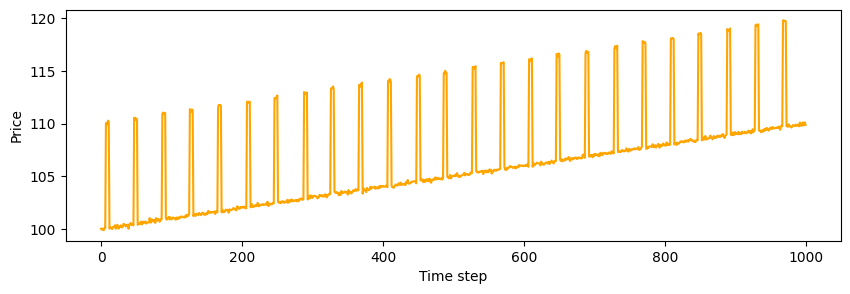

In [4]:
price, indicator = delayed_jump.simulate_series(
    T = 1000, c = 100, trend_slope = 0.01,
    freq = 40, d1 = 5, d2 = 7, jump = 10, duration=5,
    noise_std = 0.1
)

# visualize price
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(price, label="price", ls="-", c="orange")
ax.set_xlabel("Time step")
ax.set_ylabel("Price")

In [5]:
data_df = pd.DataFrame({
    'date': pd.date_range('2000-01-01', freq='D', periods=1000),
    'tic': 'A',
    'close': price,
    'indicator': indicator
})

## Stock Market

In [6]:
# from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from trading_environment.custom_env import StockTradingEnv
from finrl.meta.preprocessor.preprocessors import data_split
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [7]:
df_env = data_df.copy()

# split into train & trade/backtest periods
split_i = 700
start1, end1 = df_env['date'].iloc[0], df_env['date'].iloc[split_i]
start2, end2 = df_env['date'].iloc[split_i+1], df_env['date'].iloc[-1]
train_df = data_split(df_env, start=start1, end=end1)
trade_df = data_split(df_env, start=start2, end=end2)

print("training range:", start1, end1)
print("testing range", start2, end2)

training range: 2000-01-01 00:00:00 2001-12-01 00:00:00
testing range 2001-12-02 00:00:00 2002-09-26 00:00:00


In [8]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
tech_indicator_list = ['indicator']
state_space = 1 + 2 * stock_dim + len(tech_indicator_list) * stock_dim

env_kwargs = {
    "hmax": 100,
    "initial_amount": 5000,
    "buy_cost_pct": [0.005] * stock_dim,
    "sell_cost_pct": [0.005] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_scaling": 1,
    "num_stock_shares": [0] * stock_dim,
    # "tech_indicator_list": tech_indicator_list
    "price": "close",
    "predictors": tech_indicator_list,
    "window_size": 100
}

print(state_space)

4


In [9]:
# build training env
env_train_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=train_df, **env_kwargs))])

# build trading/backtest env
env_trade_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=trade_df, **env_kwargs))])

## Model training

In [10]:
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

In [11]:
# policy_kwargs = dict(
#     net_arch=[64, 32]
# )

# model = PPO(
#     policy="MlpPolicy",
#     env=env_train_vec,
#     ent_coef=0.10,
#     verbose=0,
#     policy_kwargs=policy_kwargs,
# )

In [12]:
policy_kwargs = dict(
    net_arch=[64, 64],
    lstm_hidden_size=16,
    n_lstm_layers=1,
    shared_lstm=False,
    enable_critic_lstm=True
)

model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=env_train_vec,

    # --- PPO rollout & update ---
    n_steps=64,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,              # long-ish horizon for cyclic pattern
    gae_lambda=0.95,

    # --- Optimization ---
    learning_rate=3e-4,      # a bit smaller since env is noise-free
    max_grad_norm=0.5,
    clip_range=0.15,         # slightly tighter clipping for stability
    vf_coef=0.5,
    ent_coef=0.10,           # non-zero exploration

    # --- Misc ---
    verbose=0,
    tensorboard_log=None,
    policy_kwargs=policy_kwargs,
)

In [ ]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=5000)
eval_callback = EvalCallback(
    env_train_vec,
    callback_on_new_best=stop_callback,
    eval_freq=1_000,
    verbose=1,
)

model.learn(total_timesteps=50_000, callback=eval_callback)

Eval num_timesteps=1000, episode_reward=263.77 +/- 0.00
Episode length: 600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=2000, episode_reward=263.42 +/- 0.00
Episode length: 600.00 +/- 0.00
Eval num_timesteps=3000, episode_reward=263.56 +/- 0.00
Episode length: 600.00 +/- 0.00
Eval num_timesteps=4000, episode_reward=266.71 +/- 0.00
Episode length: 600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=5000, episode_reward=266.90 +/- 0.00
Episode length: 600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=6000, episode_reward=267.95 +/- 0.00
Episode length: 600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=7000, episode_reward=-748.99 +/- 0.00
Episode length: 600.00 +/- 0.00
Eval num_timesteps=8000, episode_reward=269.09 +/- 0.00
Episode length: 600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=9000, episode_reward=269.09 +/- 0.00
Episode length: 600.00 +/- 0.00
Eval num_timesteps=10000, episode_reward=269.09 +/- 0.00
Episode length: 600.00 +/- 0.00
Eval num

## Evaluation

In [14]:
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest

In [15]:
trade_env = StockTradingEnv(df=trade_df, **env_kwargs)

In [16]:
res = run_backtest(
    model,
    trade_env,
    env_kwargs
)

In [17]:
c0, p0, s0 = trade_env.state_history[0, :3]
c1, p1, s1 = trade_env.state_history[-1, :3]

print('Change in net asset:', (c1 - c0) + (p1 * s1) - (p0 * s0))

Change in net asset: 77.03570483369185


c:\Users\mushj\OneDrive\Desktop\ColumbiaU MSDS\ELEN6885E - Reinforcement Learning\Final Project\rl-trading\evaluation\visualize.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["shares_delta"] = df["shares"].diff().fillna(0)


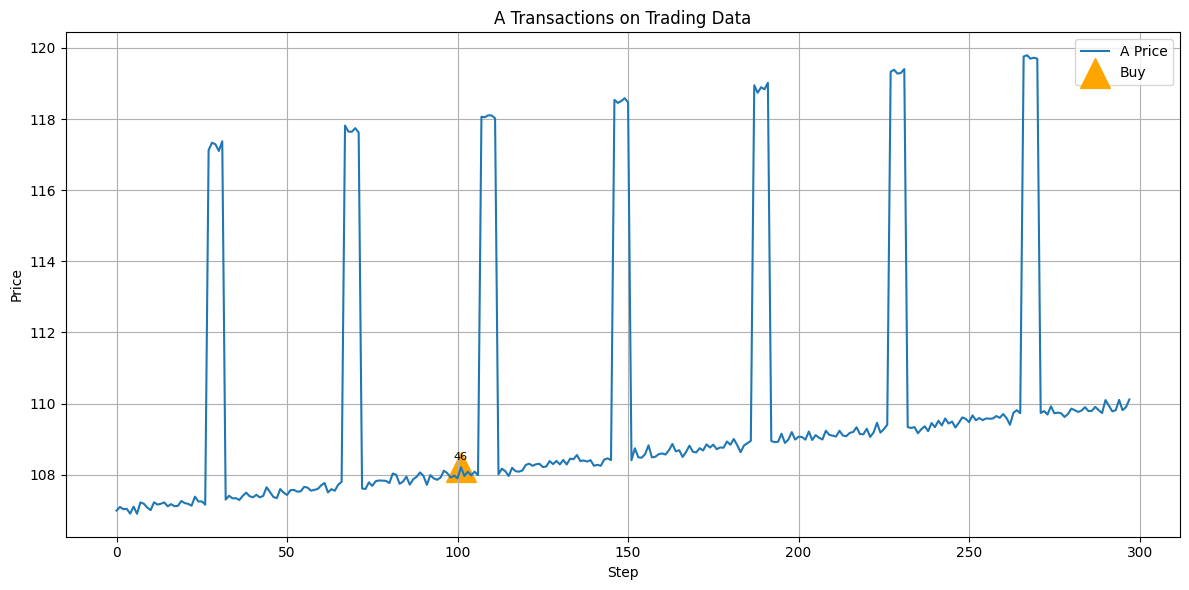

In [18]:
fig, ax = plot_trades_on_price_from_backtest(res, ticker='A')
display(fig)

## Random policy

In [25]:
env = StockTradingEnv(df=trade_df, **env_kwargs)
obs, info = env.reset()
terminated = False
while not (terminated):
    # buy/sell/hold with probs
    action = np.random.choice([-1.0, 1.0, 0.0], p=[0.10, 0.10, 0.8]).reshape(1)
    obs, reward, terminated, truncated, info = env.step(action)

c0, p0, s0 = env.state_history[0, :3]
c1, p1, s1 = env.state_history[-1, :3]

print('Change in net asset:', (c1 - c0) + (p1 * s1) - (p0 * s0))

Change in net asset: -436.4348800828857


In [26]:
lim = 1 + 2 * stock_dim
res = pd.DataFrame(env.state_history[:,:lim])
res.columns = [
    'cash',
    *['price_' + tic for tic in env.tic_list],
    *['shares_' + tic for tic in env.tic_list]
]

c:\Users\mushj\OneDrive\Desktop\ColumbiaU MSDS\ELEN6885E - Reinforcement Learning\Final Project\rl-trading\evaluation\visualize.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["shares_delta"] = df["shares"].diff().fillna(0)


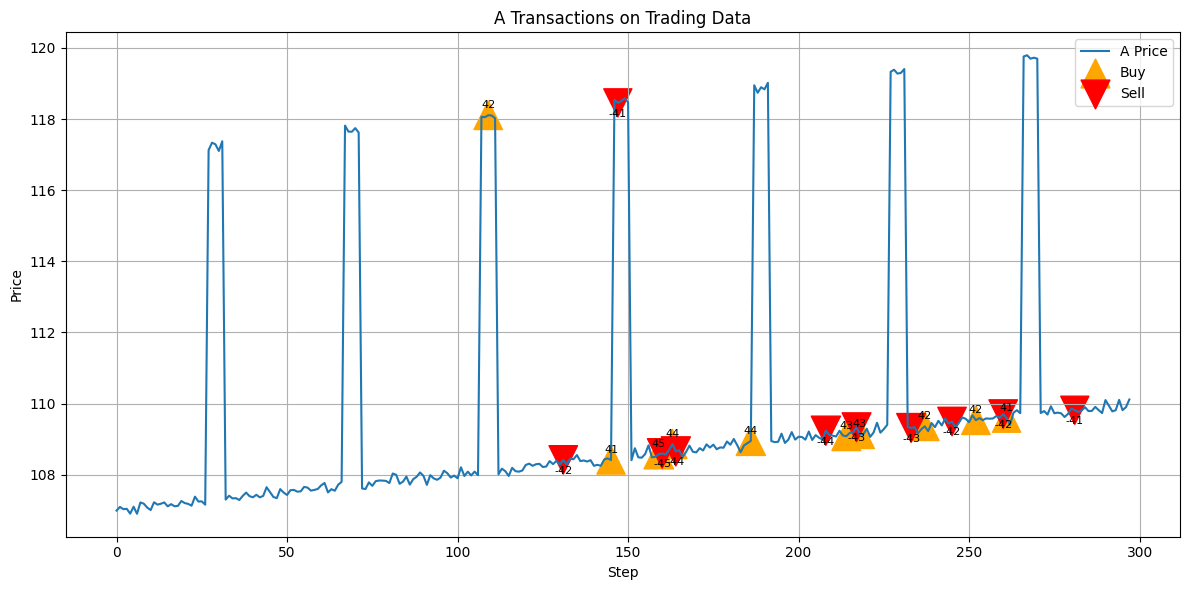

In [27]:
fig, ax = plot_trades_on_price_from_backtest(res, ticker='A')
display(fig)